In [1]:
# import libraries

import kagglehub
from kagglehub import KaggleDatasetAdapter, PolarsFrameType

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import SMOTE


In [2]:
import os

# import datasets from kaggle
dataset_dir = kagglehub.dataset_download('rikdifos/credit-card-approval-prediction')

# import applicant record csv file
app_path = os.path.join(dataset_dir, 'application_record.csv')
app = pd.read_csv(app_path)

# import credit history csv file
credit_path = os.path.join(dataset_dir, 'credit_record.csv')
credit = pd.read_csv(credit_path)

100%|██████████| 5.32M/5.32M [00:01<00:00, 4.12MB/s]

Extracting files...


In [3]:
# merge csv files on ID columm
data = pd.merge(app, credit, on="ID")
#data.head()

In [4]:
# create target variable/risk label
'''
C	= paid
0	= no delay
1-5	= increasing delinquency
'''
data['STATUS'] = data['STATUS'].replace({
    'C':0,
    '0':0,
    '1':1,
    '2':1,
    '3':1,
    '4':1,
    '5':1,
    'X':0 # means no loan for the month, treating as no risk
})

# Convert the column to integer type after replacing all string representations
data['STATUS'] = data['STATUS'].astype(int)

# credit feature engineering
# severity mapping: X/C = no delinquency (0), 0-5 = increasing past-due level (1-6)
status_severity = {'X': 0, 'C': 0, '0': 1, '1': 2, '2': 3, '3': 4, '4': 5, '5': 6}
credit['status_numeric'] = credit['STATUS'].astype(str).map(status_severity).fillna(0)
credit['is_late']  = (credit['status_numeric'] > 0).astype(int)   # any delinquency flag
credit['has_loan'] = (credit['STATUS'] != 'X').astype(int)         # active-loan flag

credit_agg = (
    credit
    .groupby('ID')
    .agg(
        max_status        = ('status_numeric', 'max'),  # worst delinquency ever seen
        num_late_payments = ('is_late',        'sum'),  # total delinquent months
        total_loan_months = ('has_loan',       'sum'),  # months with an active loan
    )
    .reset_index()
)

# late_payment_ratio: delinquent months / active-loan months (avoid div-by-zero)
credit_agg['late_payment_ratio'] = np.where(
    credit_agg['total_loan_months'] > 0,
    credit_agg['num_late_payments'] / credit_agg['total_loan_months'],
    0.0
)


# aggregate status per applicant
target = data.groupby('ID')['STATUS'].max().reset_index()

# merge back with application dataset
df = pd.merge(app, target, on="ID")
df = pd.merge(df, credit_agg, on='ID', how='left')

# rename target variable/risk label
df.rename(columns={'STATUS':'risk_label'}, inplace=True)

/tmp/ipykernel_13093/858264673.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['STATUS'] = data['STATUS'].replace({


In [5]:
# data cleaning
# handles missing values
df.isnull().sum()
df.fillna(df.median(numeric_only=True), inplace=True)

# handles duplicate values
df.drop_duplicates(inplace=True)

In [6]:
# get random sample of 3,000 rows
sample_df = df.sample(n=3000, random_state=42)

In [7]:
df.columns

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'risk_label',
       'max_status', 'num_late_payments', 'total_loan_months',
       'late_payment_ratio'],
      dtype='object')

In [8]:
df.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,risk_label,max_status,num_late_payments,total_loan_months,late_payment_ratio
count,3.645700e+04,36457.000000,3.645700e+04,36457.000000,36457.000000,36457.0,36457.000000,36457.000000,36457.000000,36457.000000,36457.000000,36457.000000,36457.000000,36457.000000,36457.000000
mean,5.078227e+06,0.430315,1.866857e+05,-15975.173382,59262.935568,1.0,0.225526,0.294813,0.089722,2.198453,0.117700,1.031818,8.290013,17.329045,0.585854
std,4.187524e+04,0.742367,1.017892e+05,4200.549944,137651.334859,0.0,0.417934,0.455965,0.285787,0.911686,0.322257,0.647176,8.021043,14.979895,0.400009
min,5.008804e+06,0.000000,2.700000e+04,-25152.000000,-15713.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.042028e+06,0.000000,1.215000e+05,-19438.000000,-3153.000000,1.0,0.000000,0.000000,0.000000,2.000000,0.000000,1.000000,3.000000,5.000000,0.194444
50%,5.074614e+06,0.000000,1.575000e+05,-15563.000000,-1552.000000,1.0,0.000000,0.000000,0.000000,2.000000,0.000000,1.000000,6.000000,13.000000,0.600000
75%,5.115396e+06,1.000000,2.250000e+05,-12462.000000,-408.000000,1.0,0.000000,1.000000,0.000000,3.000000,0.000000,1.000000,11.000000,26.000000,1.000000
max,5.150487e+06,19.000000,1.575000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000,1.000000,6.000000,61.000000,61.000000,1.000000


In [9]:
# applicant feature engineering

# years_employed: DAYS_EMPLOYED is negative for currently employed people
# positive values indicate unemployed — treat those as 0 years employed
df['years_employed'] = np.where(
    df['DAYS_EMPLOYED'] < 0,
    (-df['DAYS_EMPLOYED']) / 365.25,
    0.0
)

# income_per_person: household financial capacity
df['income_per_person'] = (
    df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS'].replace(0, np.nan)
)


**Exploratory Data Analyis**

**1. Distribution Plots**


*   Histogram 1: total income
*   Histogram 2: years employed

**2. Risk Comparison Plots**


*   Box plot: income vs risk label
*   Bar char: risk rate by income type

**3. Correlation Heatmap: features/attributes by risk**



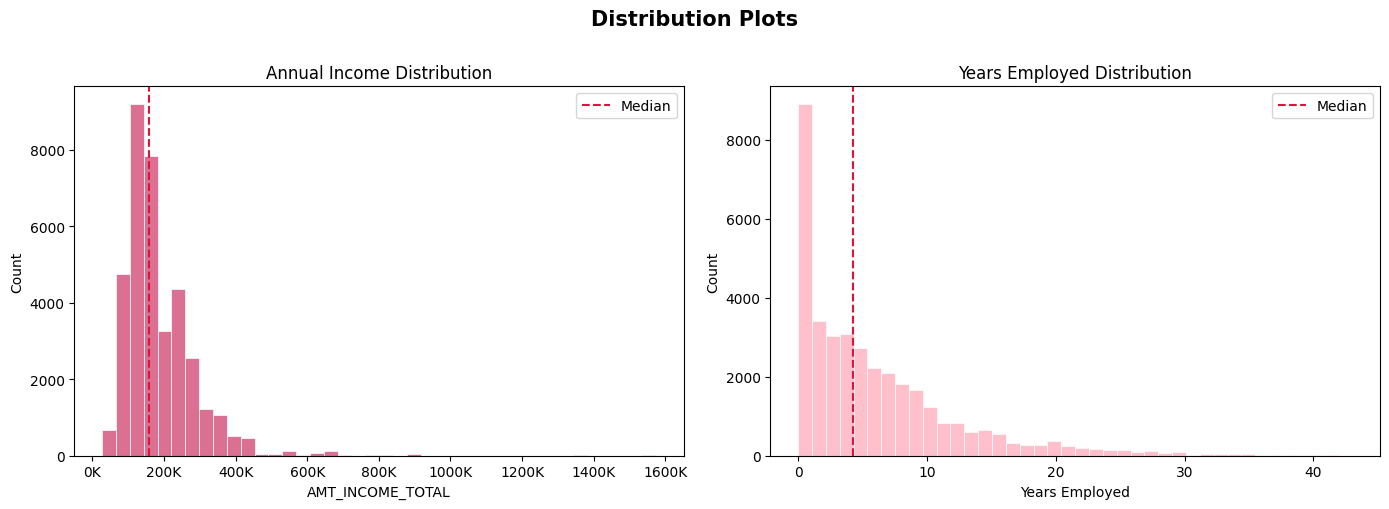

In [10]:
# distribution plots

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution Plots', fontsize=15, fontweight='bold', y=1.01)

# histogram 1: total income
axes[0].hist(
    df['AMT_INCOME_TOTAL'].dropna(),
    bins=40, color='palevioletred', edgecolor='white', linewidth=0.5
)
axes[0].set_title('Annual Income Distribution', fontsize=12)
axes[0].set_xlabel('AMT_INCOME_TOTAL')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K')
)
axes[0].axvline(
    df['AMT_INCOME_TOTAL'].median(),
    color='crimson', linestyle='--', linewidth=1.5, label='Median'
)
axes[0].legend()

# histogram 2: years employed
axes[1].hist(
    df['years_employed'].dropna(),
    bins=40, color='pink', edgecolor='white', linewidth=0.5
)
axes[1].set_title('Years Employed Distribution', fontsize=12)
axes[1].set_xlabel('Years Employed')
axes[1].set_ylabel('Count')
axes[1].axvline(
    df['years_employed'].median(),
    color='crimson', linestyle='--', linewidth=1.5, label='Median'
)
axes[1].legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_13093/2310710374.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


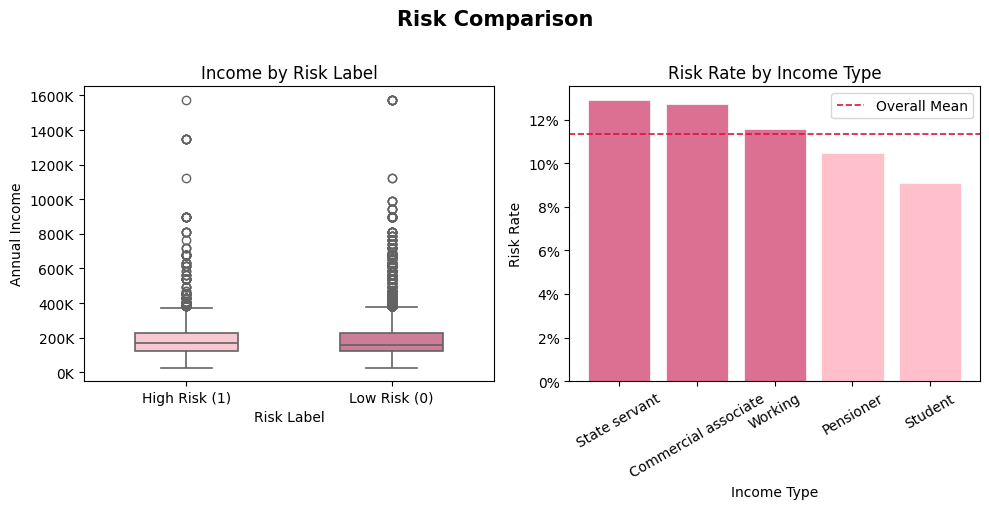

In [11]:
# risk comparison

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Risk Comparison', fontsize=15, fontweight='bold', y=1.01)

# boxplot: income vs risk_label
risk_labels_map = {0: 'Low Risk (0)', 1: 'High Risk (1)'}
plot_df = df.copy()
plot_df['Risk Group'] = plot_df['risk_label'].map(risk_labels_map)

sns.boxplot(
    data=plot_df,
    x='Risk Group', y='AMT_INCOME_TOTAL',
    palette=['pink', 'palevioletred'],
    width=0.5, linewidth=1.2,
    ax=axes[0]
)
axes[0].set_title('Income by Risk Label', fontsize=12)
axes[0].set_xlabel('Risk Label')
axes[0].set_ylabel('Annual Income')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K')
)

# bar chart: risk rate by income type
risk_rate = (
    df.groupby('NAME_INCOME_TYPE')['risk_label']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
risk_rate.columns = ['Income Type', 'Risk Rate']

bar_colors = ['palevioletred' if r > risk_rate['Risk Rate'].mean() else 'pink'
              for r in risk_rate['Risk Rate']]
axes[1].bar(risk_rate['Income Type'], risk_rate['Risk Rate'],
            color=bar_colors, edgecolor='white', linewidth=0.5)
axes[1].axhline(risk_rate['Risk Rate'].mean(),
                color='crimson', linestyle='--', linewidth=1.2, label='Overall Mean')
axes[1].set_title('Risk Rate by Income Type', fontsize=12)
axes[1].set_xlabel('Income Type')
axes[1].set_ylabel('Risk Rate')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{y:.0%}')
)
axes[1].legend()

plt.tight_layout()
plt.show()

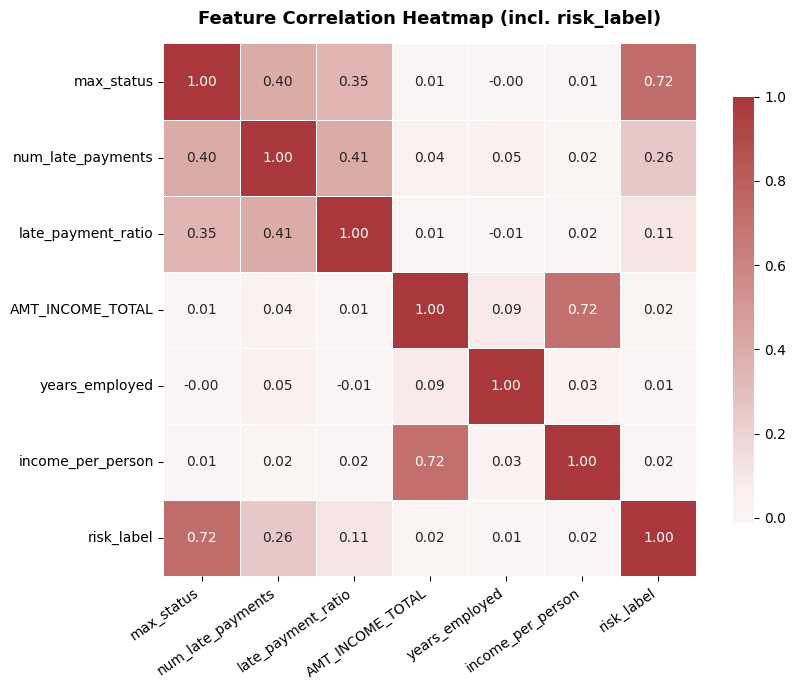

In [12]:
# correlation heatmap

heatmap_cols = [
    'max_status', 'num_late_payments', 'late_payment_ratio',
    'AMT_INCOME_TOTAL', 'years_employed', 'income_per_person',
    'risk_label'
]

corr = df[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='vlag', center=0,
    linewidths=0.5, linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title('Feature Correlation Heatmap (incl. risk_label)',
             fontsize=13, fontweight='bold', pad=14)
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

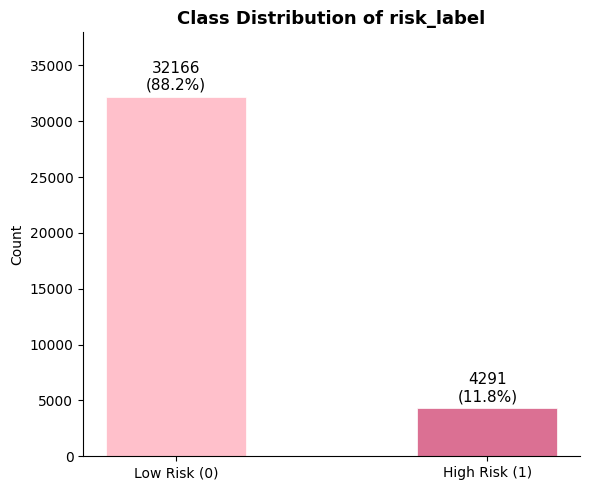

In [13]:
# class distribution

counts = df['risk_label'].value_counts().sort_index()
labels = ['Low Risk (0)', 'High Risk (1)']
colors = ['pink', 'palevioletred']

fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(labels, counts.values, color=colors,
              edgecolor='white', linewidth=0.5, width=0.45)

# show count + percentage on each bar
total = counts.sum()
for bar, count in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total * 0.01,
        f'{count}\n({count/total:.1%})',
        ha='center', va='bottom', fontsize=11
    )

ax.set_title('Class Distribution of risk_label',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.18)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [14]:
# prep features & encode categoricals

feature_cols = [
    'years_employed',
    'income_per_person',
    'AMT_INCOME_TOTAL',
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'FLAG_WORK_PHONE',
    'FLAG_PHONE',
    'FLAG_EMAIL',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
]

df['years_employed'] = abs(df['DAYS_EMPLOYED']) / 365     # days to years employed
df['income_per_person'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']    # income per family member

model_df = df[feature_cols + ['risk_label']].copy()

for col in ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY']:
    if model_df[col].dtype == object:
        model_df[col] = (model_df[col] == 'Y').astype(int)

le = LabelEncoder()
for col in model_df.select_dtypes(include='object').columns:
    model_df[col] = le.fit_transform(model_df[col].astype(str))

model_df.fillna(model_df.median(numeric_only=True), inplace=True)

print('Feature matrix shape :', model_df.drop(columns='risk_label').shape)
print('Features used        :', feature_cols)
print('\nClass balance:\n', model_df['risk_label'].value_counts())

Feature matrix shape : (36457, 14)
Features used        : ['years_employed', 'income_per_person', 'AMT_INCOME_TOTAL', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE']

Class balance:
 risk_label
0    32166
1     4291
Name: count, dtype: int64


In [15]:
# train-test split (80/20)

X = model_df.drop(columns='risk_label')
y = model_df['risk_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# scale features for log reg
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# SMOTE on training set to address class imbalance
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

neg, pos = np.bincount(y_train)
spw = neg / pos

In [16]:
# train models

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)

rf = RandomForestClassifier(
    n_estimators=200, max_depth=8,
    min_samples_leaf=5, class_weight='balanced_subsample',
    random_state=42, n_jobs=-1
)
rf.fit(X_train_sc, y_train)

xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric='logloss',
    random_state=42, n_jobs=-1
)
xgb.fit(X_train_sc, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [17]:
# evaluate models

def evaluate_model(name, model, X_te, y_te):
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    report = classification_report(y_te, y_pred, output_dict=True)
    auc    = roc_auc_score(y_te, y_proba)
    pr_auc = average_precision_score(y_te, y_proba)

    print(f'\n{"-"*50}')
    print(f'  {name}')
    print(f'{"-"*50}')
    print(classification_report(y_te, y_pred,
                                target_names=['Low Risk', 'High Risk']))
    print(f'  ROC-AUC        : {auc:.4f}')
    print(f'  PR-AUC (Avg P) : {pr_auc:.4f}')

    return {
        'Model'    : name,
        'Accuracy' : report['accuracy'],
        'Precision': report['1']['precision'],
        'Recall'   : report['1']['recall'],
        'ROC-AUC'  : auc,
        'PR-AUC'   : pr_auc,
        'y_pred'   : y_pred,
        'y_proba'  : y_proba,
    }

results = {}
results['Logistic Regression'] = evaluate_model('Logistic Regression', lr, X_test_sc, y_test)
results['Random Forest']       = evaluate_model('Random Forest',       rf, X_test_sc, y_test)
results['XGBoost'] = evaluate_model('XGBoost', xgb, X_test_sc, y_test)



--------------------------------------------------
  Logistic Regression
--------------------------------------------------
              precision    recall  f1-score   support

    Low Risk       0.90      0.54      0.68      6434
   High Risk       0.13      0.52      0.21       858

    accuracy                           0.54      7292
   macro avg       0.51      0.53      0.44      7292
weighted avg       0.81      0.54      0.62      7292

  ROC-AUC        : 0.5422
  PR-AUC (Avg P) : 0.1396

--------------------------------------------------
  Random Forest
--------------------------------------------------
              precision    recall  f1-score   support

    Low Risk       0.91      0.76      0.83      6434
   High Risk       0.21      0.46      0.28       858

    accuracy                           0.73      7292
   macro avg       0.56      0.61      0.56      7292
weighted avg       0.83      0.73      0.77      7292

  ROC-AUC        : 0.6584
  PR-AUC (Avg P) : 0.226

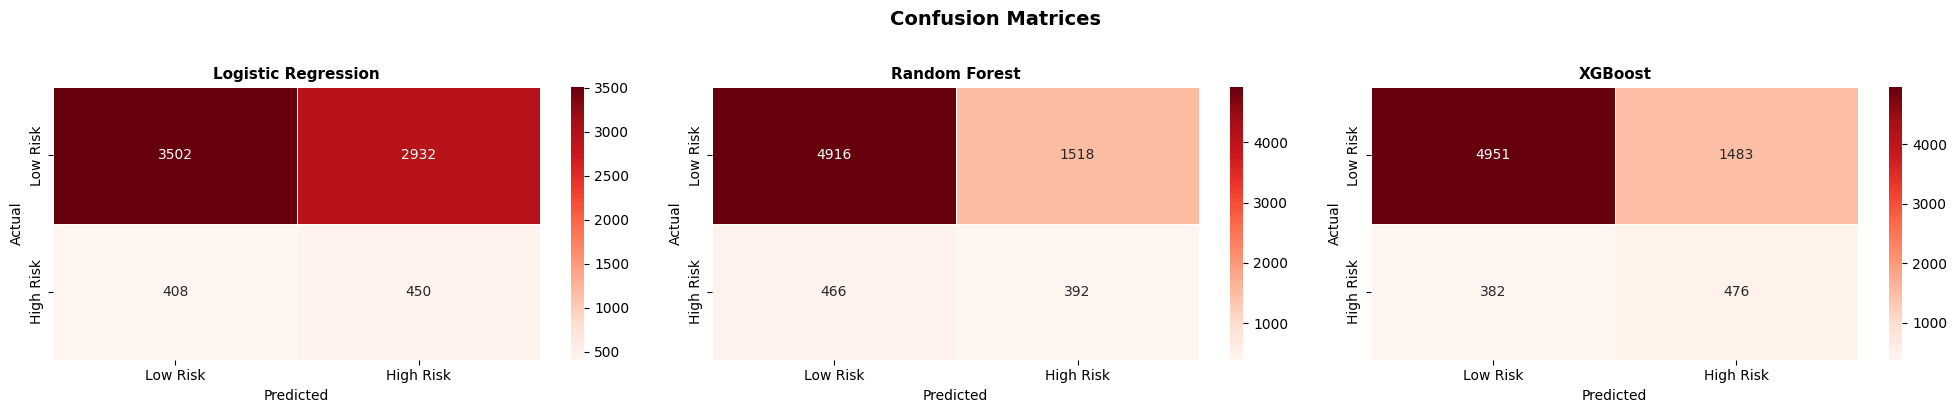

In [18]:
# confusion matrix
model_names = ['Logistic Regression', 'Random Forest', 'XGBoost']
fig, axes = plt.subplots(1, 3, figsize=(20, 4))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)

for ax, name in zip(axes, model_names):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d',
        cmap='Reds', linewidths=0.5,
        xticklabels=['Low Risk', 'High Risk'],
        yticklabels=['Low Risk', 'High Risk'],
        ax=ax
    )
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

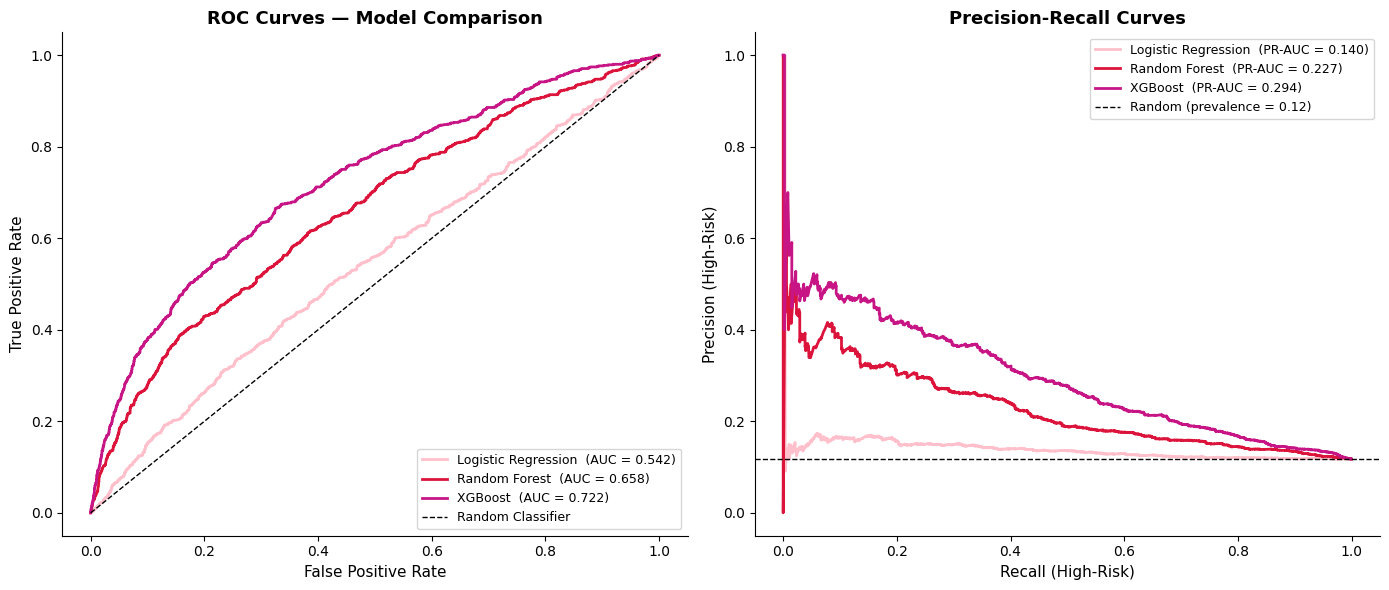

In [19]:
palette = {
    'Logistic Regression': 'pink',
    'Random Forest'      : 'crimson',
    'XGBoost'            : 'mediumvioletred',
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for name in model_names:
    c = palette[name]
    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_proba'])
    ax1.plot(fpr, tpr,
             label=f'{name}  (AUC = {results[name]["ROC-AUC"]:.3f})',
             color=c, linewidth=2)
    # PR curve
    prec, rec, _ = precision_recall_curve(y_test, results[name]['y_proba'])
    ax2.plot(rec, prec,
             label=f'{name}  (PR-AUC = {results[name]["PR-AUC"]:.3f})',
             color=c, linewidth=2)

ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate', fontsize=11)
ax1.set_title('ROC Curves — Model Comparison', fontsize=13, fontweight='bold')
ax1.legend(loc='lower right', fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

baseline = y_test.mean()
ax2.axhline(baseline, color='k', linestyle='--', linewidth=1,
            label=f'Random (prevalence = {baseline:.2f})')
ax2.set_xlabel('Recall (High-Risk)', fontsize=11)
ax2.set_ylabel('Precision (High-Risk)', fontsize=11)
ax2.set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()



── Model Performance Summary ──
                     Accuracy  Precision  Recall  ROC-AUC  PR-AUC
Model                                                            
Logistic Regression    0.5420     0.1331  0.5245   0.5422  0.1396
Random Forest          0.7279     0.2052  0.4569   0.6584  0.2266
XGBoost                0.7442     0.2430  0.5548   0.7221  0.2942


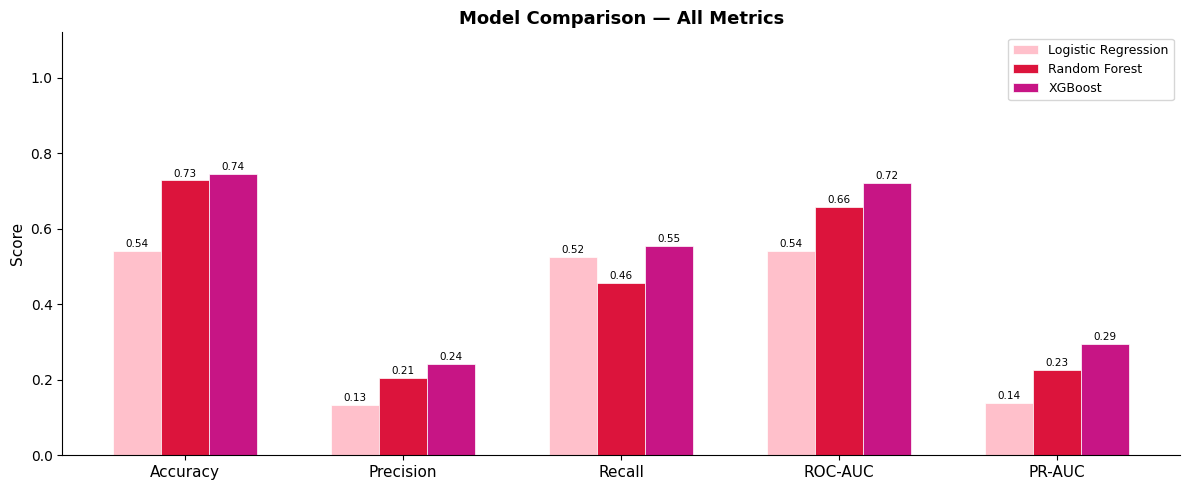

In [20]:
# summary

metrics_df = pd.DataFrame([
    {
        'Model'    : name,
        'Accuracy' : results[name]['Accuracy'],
        'Precision': results[name]['Precision'],
        'Recall'   : results[name]['Recall'],
        'ROC-AUC'  : results[name]['ROC-AUC'],
        'PR-AUC'   : results[name]['PR-AUC'],
    }
    for name in model_names
])

print('\n── Model Performance Summary ──')
print(metrics_df.set_index('Model').round(4).to_string())

metric_cols = ['Accuracy', 'Precision', 'Recall', 'ROC-AUC', 'PR-AUC']
x     = np.arange(len(metric_cols))
width = 0.22
colors_bar = ['pink', 'crimson', 'mediumvioletred']


fig, ax = plt.subplots(figsize=(12, 5))

for i, name in enumerate(model_names):
    vals = [results[name][m] for m in metric_cols]
    bars = ax.bar(x + i * width, vals, width,
                  label=name, color=colors_bar[i],
                  edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{v:.2f}',
            ha='center', va='bottom', fontsize=7.5
        )

ax.set_xticks(x + width)
ax.set_xticklabels(metric_cols, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Comparison — All Metrics', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()
